# Probability Theory

The concept of probability of a particular event is subject to different interpretations. There have been two main interpretation to define probability.

1. Frequentists (Empirical) Approach: Frequentists define probability in terms of frequency of occurrence, as a percentage or fraction of success or occurrence of the event (from the event space $E$) in all possible outcomes of similar situations (called the sample space $\Omega$). Probability of coin toss returns head. $$Probability = \dfrac{\# \text{ of favorable outcomes}}{\# \text{ of all possible outcomes}} = \frac{E}{\Omega}$$

This interpretation of probability of an event here is the limit of the relative frequency with which the event occurs, in repeated trials (upto $\infty$) under the same conditions.
$$P(E) = \lim_{n\to\infty} \frac{n_E}{n}$$


2. Bayesian (Subjective Belief) Approch: which interprets the concept of probability as reasonable expectation representing a state of knowledge or as quantification of a personal belief. Bayesian interpretation can be seen as an extension of propositional logic that enables reasoning with hypotheses with propositions whose truth or falsity is unknown. To evaluate the probability of a hypothesis, the Bayesian probabilist specifies a prior probability and update it with new relevant data or evidence to a posterior probability. eg. Probability that the president will be re-elected.

Despite the different interpretation for probability, we have same general rules and a single way of evaluating, leading to unique answers, but in statistical questions, there may not be a unique answers. Different statistical methods have different desirable properties leading to different answers. Often times misuse of methods for a particular situation could lead to erroneous answers. The two approaches permeates to statistics as well

- Classical Statistics : Parameter estimation without Priors
  - Maximum Likelihood Estimation (MLE)
  - Estimating Sample Mean
  - Confidence Intervals (CIs) around the estimate
- Bayesian Statistics



In [4]:
import math, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

Probability of  ['H' 'T']  are  [0.497 0.503]


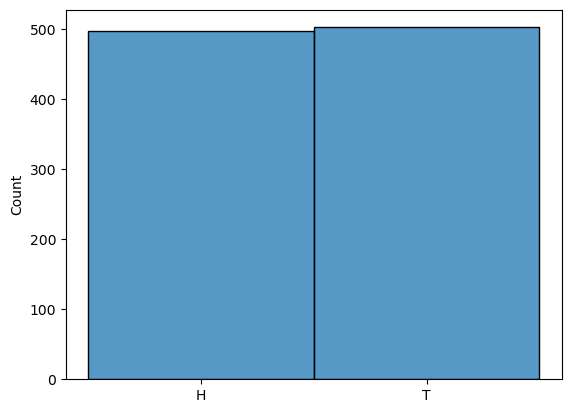

In [57]:
# Eg: Probability of Heads in flipping a fair coin

# Sample Space: set of all possible outcomes that are mutually exclusive & collectively exhaustive
S = {'H', 'T'}  # Sampling from Set is inefficient, ∵ most sampling technique requires the population in a deterministic order
S = list(S)

num_exp = 1000
exp_results = np.random.choice(S, num_exp)  
# Random Sample or simulations from the set assuming uniform distribution

unique, counts = np.unique(exp_results, return_counts=True)
P = counts / num_exp   

print("Probability of ", unique, " are ", P )

sns.histplot(exp_results)
plt.show()

## Probabilistic Space

A probabilistic space that models random process consists of three important elements:
1. **Sample Space** $\Omega$ or $S$: A set of all possible outcomes of an experiments  where the outcomes are mutally exclusive & collectively exhaustive. Since a set of all possible outcomes could be infinite, we need to select the right level of granularity and ignore the irrelevant details. Sample Spaces can be discrete & finite such as coin toss or it could be discrete and infinite such as continuous outcomes such as dart location in a rectangular target where the probability of getting a specific point (a,b) with infinite precision is effectively 0 .
2. **Event Space** $E \text{ or } A,B,C,\dots$: A collection of events, where each event is a subset of sample space $E \subset S$. Events are usually combined through set operations union, intersection, complement.
3. **Probability Distribution function (or measure)** $P : E \rightarrow \mathbb R$, i.e. a function that takes in an event and returns a real number between [0, 1] indicating the chance of the event occurring following certain probabilistic laws or axioms. Since some outcomes are more likely than others, we need to assign different probability to each outcomes, probability distribution function does this assignment.

In [ ]:
# Discrete Finite Uniform Case: Two Rolls of Tetrahedral Die
# X = First Roll's Outcome, Y = Second Roll's Outcome

S = np.array([(X, Y) for X in range(1,5) for Y in range(1,5)])

P_X_1 = sum(S[:, 0] == 1) / len(S)   # P(X = 1) = 1/4
print(" P(X=1) = ", P_X_1)

Z_min_4 = [1 for i,j in S if min(i,j)==4]
P_Z_min_4 = len(Z_min_4)/len(S)            # P(min(x,y) =4 ) = 1/16
print("P(Z =min(x,y) = 4 ) = ", P_Z_min_4)

P_X_gt_Y = sum(S[:, 0 ] > S[:, 1])/len(S)  # X strictly greater than Y
print("P(X > Y ) = ", P_X_gt_Y)

P_sum_even = sum((S[:, 0 ] + S[:, 1])%2 == 0)/len(S)  # sum of two outcome is even
print("P(X + Y is even) = ", P_sum_even)

 P(X=1) =  0.25
P(Z =min(x,y) = 4 ) =  0.0625
P(X > Y ) =  0.375
P(X+Y is even) =  0.5


In [ ]:
# Continuous Uniform Case: Dart on a Square



0.0625

In [ ]:
# Discrete Infinite Sample space
## Check if Probability laws are satisfied, i.e  P(Omega) = 1
## eg P(n) = 1/2^n for n = 1,2,...
## find P({3,6,9,...})

### Probabilistic laws or axioms

- Non-Negativity: $P(E) \geq 0$: also implies $P(\emptyset) = 0$
- Normalization: $P(\Omega) = 1$, i.e. $\Omega$ is collectively exhaustive. $\therefore P(E) \leq 1$
- Finite Additivity: For two disjoint events (i.e. $A \cap B = \emptyset$): $$P(A \cup B) = P(A) + P(B)$$
  - Extends to a set of mutually exclusive events: $$P \left ( \bigcup_{i=1}^n E_i \right ) = P(E_1 \cup E_2 \cup \dots E_n) = P(E_1) + P(E_2) + \dots + P(E_n) = \sum_{i=1}^n P(E_i)$$
  - Defines compliments with normalization: $$P(\omega) = P(E) + P(E^c) = 1, \quad \therefore P(E^c) = 1 - P(E) $$
- If events A & B are such that $A \subseteq B$ then $P(A) \leq P(B)$
- For overlapping any two overlapping events A & B:
  - Union bound: $P(A U B) \leq P(A) + P(B)$
    - $P(A \cup B \cup C) = P(A) + P(A^c \cap B) + P(A^c \cap B^c \cap C)$ , can derive more visualizing through set diagrams
  - $P(A \cup B) = P(A) + P(B) - P (A \cap B)$


### Conditional Probability

Conditional Probability $P(A | B) = \frac{P(A \cap B)}{P(B)}$ as long as $P(B) > 0$, it follows the above axioms as
    - $P(A|B) \geq 0$
    - $P(B|B)=1$
    - If $A_1, A_2, \ldots, A_k$ are mutually exclusive events then $$P(A_1\cup A_2\cup \ldots \cup A_k|B)=P(A_1|B)+P(A_2|B)+\ldots+P(A_k|B)$$
- Conditional probability allows to estimate the probability that events A & B both occuring as Multiplication rule of probability or composite probability: $$P(A \cap B) = P(A|B) \times P(B) = P(B|A) \times P(A)$$ 
- This rule can be extended to three or more events as well $$\begin{aligned}P(A \cap B \cap C) &=P[(A \cap B) \cap C)] \\ & =\underbrace{P(C | A \cap B)}_{a} \times \underbrace{P(A \cap B)}_{b} \\ &= \underbrace{P(C | A \cap B)}_{a} \times \underbrace{P(B | A) \times P(A)}_{b} \end{aligned}$$
- Generalize the Total Probability Theorem: $$P(B) = P(B \cap A) + P(B \cap A^c)$$ which allows to partition the sample space as weighted average of probabilities of an Event i.e $$P(B) = P(A_1) \times P(B|A_1) + P(A_2) \times P(B|A_2) + \dots P(A_n) \times P(B|A_n)$$

In [42]:
# Conditional Probability is important when asking conditional questions on the data

renalTest_df = pd.DataFrame({
    'Truth': ['Renal Disease', 'Healthy', 'Total'],
    'TestPositive': [44, 10, 54],
    'TestNegative': [23, 60, 83],
    'TotalTest': [67, 70, 137]
})

print(renalTest_df)

# If a person has renal disease, what is the probability of testing positive?
# Sensitivity of diagnostic test 
sensitivity = renalTest_df[renalTest_df["Truth"]=="Renal Disease"]["TestPositive"].values / renalTest_df[renalTest_df["Truth"]=="Renal Disease"]["TotalTest"].values
print(f"Sensitivity i.e. P(T+|D) = {sensitivity[0]}")

# If a person receive a positive test, what is the probability that the person actually has the disease?
# "positive predictive value" of diagnostic test
PP = renalTest_df[renalTest_df["Truth"]=="Renal Disease"]["TestPositive"].values / renalTest_df[renalTest_df["Truth"]=="Total"]["TestPositive"].values
print(f"Positive Predicitive value i.e P(D|T+) = {PP[0]}")

# P(D|T+) \neq p(T+|D)


           Truth  TestPositive  TestNegative  TotalTest
0  Renal Disease            44            23         67
1        Healthy            10            60         70
2          Total            54            83        137
Sensitivity i.e. P(T+|D) = 0.6567164179104478
Positive Predicitive value i.e P(D|T+) = 0.8148148148148148


### Independence of Events

Events A and B are independent events if the occurrence of one of them does not affect the probability of the occurrence of the other, or provide no information about the occurence of other. i.e., two events are independent if either: $ P(B|A)=P(B) : P(A) > 0$  or $P(A|B)=P(A) : P(B)>0$. Independence of events allows substitution of conditionals for the multiplicative rule $$\begin{aligned} P(A \cap B) &= P(A|B) \times P(B) \\ &= P(A) \times P(B) \end{aligned}$$. This is considered as the alternative definition of independent events i.e. Events A and B are independent events if and only if $P(A\cap B)=P(A)\times P(B)$. Else events are dependent and $P(A \cap B) = P(A) P(B|A)$
  - Note: Disjoint events are dependent events i.e if A has occurred implies that event $P(B|A)=0$
  - Theorem: If A and B are independent event, then 
    - A and B' are independent
    - A' and B are indepdendent
    - A' and B' are independent


Three events A, B and C are mutually independent if and only if the following two conditions hold:
- The events are pairwise independent, i.e. 
  - $P(A\cap B)=P(A)\times P(B)$, 
  - $P(A\cap C)=P(A)\times P(C)$ and 
  - $P(B\cap C)=P(B)\times P(C)$
- $P(A\cap B\cap C)=P(A)\times P(B)\times P(C)$

The idea of mutual independence can be extended to four or more events — each pair, triple, quartet, and so on, must satisfy the above type of multiplication rule.

In [2]:
# Example of non-mutually independent events: Roulette wheel

N = 36
# Event that a spin of roulette wheel yields a RED number
Red = {1, 2, 3, 4, 5, 10, 11, 12, 13, 24, 25, 26, 27, 32, 33, 34, 35, 36}

# Event that a spin of the wheel yields an EVEN number
Even = {2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36}

# Event that a spin of the wheel yields a number no greater than 18
GT18 = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18}

# Pairwise Independence
P_Red_Even = len(Red.intersection(Even)) / N
P_Red_GT18 = len(Red.intersection(GT18)) / N
P_Even_GT18 = len(Even.intersection(GT18)) / N

print(f"{P_Red_Even = },\n{P_Red_GT18 = },\n{P_Even_GT18 = }")

P_Red_Even_GT18 = len(Red.intersection(Even).intersection(GT18)) / N

print(f"{P_Red_Even_GT18 = }")
# Not Mutually independent events


P_Red_Even = 0.25,
P_Red_GT18 = 0.25,
P_Even_GT18 = 0.25
P_Red_Even_GT18 = 0.1111111111111111


### Bayes Rule

Since $$\begin{aligned} P(A \cap B) &=  P(B \cap A)\\ \therefore P(A|B) \times P(B) &= P(B|A) \times P(A) \\ P(A|B) &= \frac{P(B|A) \times P(A)}{P(B)}\end{aligned}$$

If we consider the case of updating the probabilities of hypotheses "H" when given evidence "E". $$P(H|E) = \frac{P(E|H)P(H)}{P(E)}$$

- P(H) is the prior probability of H. It represents our belief in the hypothesis or probability that the hypothesis H occurs, known prior to observing the evidence or any information. 
- P(E) is the marginal likelihood of evidence or just Evidence. It represents the total probability of observing the evidence.
- P(E∣H) is the likelihood. It represents the probability of observing the evidence E if the hypothesis H is true.
- P(H∣E) is the posterior probability. It represents the revised belief about the hypothesis H given the event has occured, i.e probability of the hypothesis H being true, given the observed evidence E.


In [14]:
production_defects_df = pd.DataFrame({
    'Factory': ['A', 'B', 'C'],
    'FractionTotalProduction': [0.35, 0.35, 0.30],
    'Probability_defect': np.array([15, 10, 20])/1000,
})
print(production_defects_df)

#  If a randomly selected lamp is defective, what is the probability that the lamp was manufactured in factory C ?

P_defective_C = production_defects_df.loc[production_defects_df['Factory'] == 'C', 'Probability_defect'].values[0]
P_C = production_defects_df.loc[production_defects_df['Factory'] == 'C', 'FractionTotalProduction'].values[0]
P_defective = sum(production_defects_df["FractionTotalProduction"] * production_defects_df["Probability_defect"])

P_C_defective =  P_C * P_defective_C / P_defective

P_C_defective

  Factory  FractionTotalProduction  Probability_defect
0       A                     0.35               0.015
1       B                     0.35               0.010
2       C                     0.30               0.020


0.4067796610169492

In [5]:
# Disease

P_D = 1/100  # Disease is found in 1% of the population
P_TPositive_D = 95/100  # Test is positive in 95% of the actual disease cases P(T+ | D)

# If the person has the disease, what is the probability that the test is positive?
sensitivity = P_TPositive_D  # P(T+ | D)
# If the person does not have the disease, what is the probability that the test is negative?
specificity = P_TPositive_D  # P(T- | ~D)

# If a person is free of the disease, then the probability that the diagnostic test comes back positive is
P_TPositive_Healthy = 1 - P_TPositive_D

# given that the blood test is positive for the disease, what is the probability that a person actually has the disease?
P_TPositive = P_TPositive_D * P_D + P_TPositive_Healthy * (1 - P_D)
P_D_TPositive = P_TPositive_D * P_D / P_TPositive
print(P_D_TPositive)
#  Table can be used as an alternative way of finding "reverse conditional probabilities such as P(D|T+), 
#  when you know the the "forward conditional probability" P(T+|D)


# Even though the Test for disease for actual cases is 95% accurate, because of the rarity of the disease, 
# the test is seemingly not accurate enough to predict if a person has a disease. 
# Hence even if the test is positives, the person is unlikely to have the dieases

# Strategy used to improve accuracy is retesting
# In this case, the population of interest is not all people, but instead those people who got a positive result on a first test. 
P_D = P_D_TPositive
# If a second blood test on a person comes back positive for the disease, what is the probability that the person actually has the disease now?
P_TPositive = P_TPositive_D * P_D + P_TPositive_Healthy * (1 - P_D)
P_D_TPositive = P_TPositive_D * P_D / P_TPositive
print(P_D_TPositive)


0.16101694915254225
0.7847826086956519


### ?


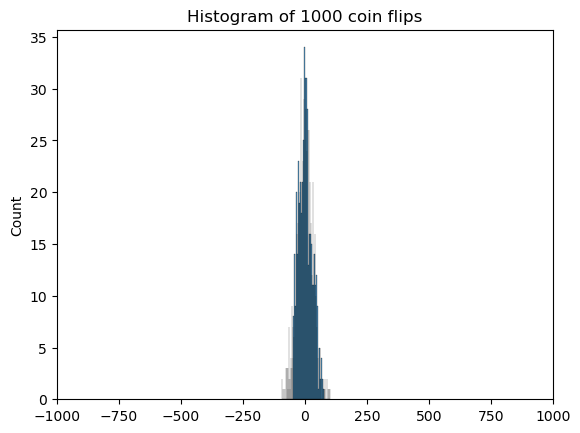

In [64]:
# Generate k coin flips and repeat the experiment n times
S = {1:'H', -1:'T'}  # Sample Space

def gen_counts(k=1000, n=1000):
  exp_results = 2 * (np.random.rand(n, k) > 0.5) - 1   # matrix of n X k with value 1 and -1
  S = np.sum(exp_results, axis=0)
  return S

k, n = 1000 , 1000
S = gen_counts(k=k,n=n)
sns.histplot(T, discrete=True).set(title=f"Histogram of {k} coin flips")
plt.xlim(-k,k)
plt.show()


Here the sum($S_{1000}$) is not 0 but distributed close to 0. Using probability theory we can calculate how small is $|S_k|$. It can be shown that $|S_k| \geq 4 \sqrt(k)$ which is smaller than 2e-8. As shown in the simulation below.

If $ k \rightarrow 0$, then $4 \sqrt k / k = 4 / \sqrt k \rightarrow 0$ 

$\therefore if k \rightarrow 0, S_k /k \rightarrow 0$

<Figure size 1300x350 with 0 Axes>

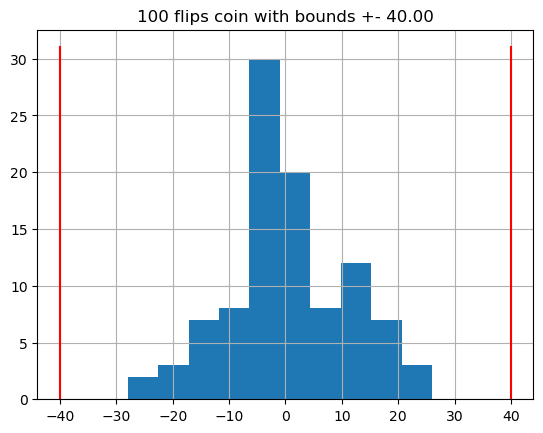

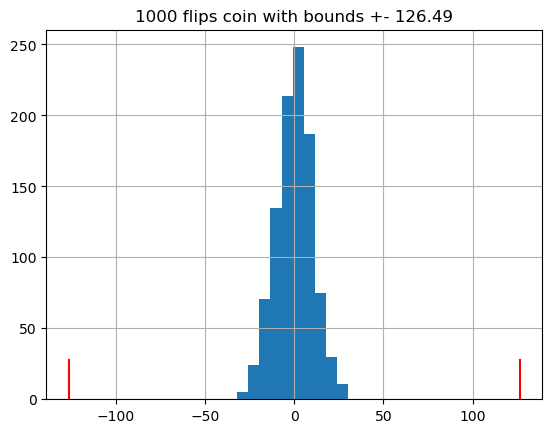

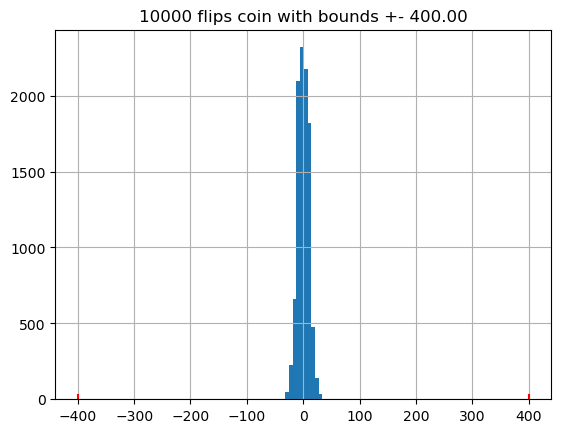

In [73]:
from math import sqrt

plt.figure(figsize=[13,3.5])
for j in range (2,5):
  k = 10**j
  counts = gen_counts(k=k, n=100)
  plt.subplots(1)
  d = 4 * sqrt(k)
  plt.hist(counts, bins=10)
  plt.title(f"{k} flips coin with bounds +- {d:.2f}")
  plt.plot([-d, -d],[0,3*10^(j-1)], 'r')
  plt.plot([d, d],[0,3*10^(j-1)], 'r')
  plt.grid()
  plt.show()


Probability of  [1 2 3 4 5 6]  are  [0.172 0.193 0.186 0.15  0.146 0.153]


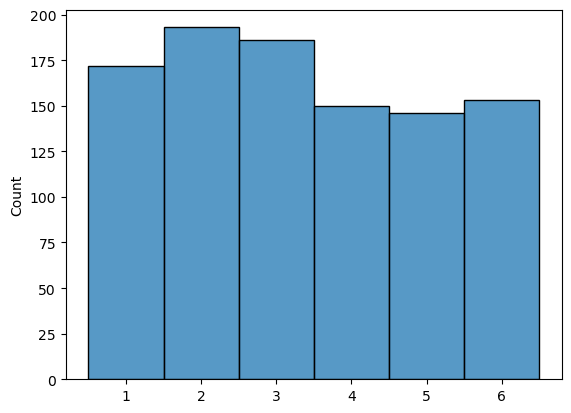

In [80]:
# Rolling a Dice

S = [1, 2, 3, 4, 5, 6]    # Sample Space

num_exp = 1000
exp_results = np.random.choice(S,num_exp)  # Random Sample or simulations from the set assuming uniform distribution

unique, counts = np.unique(exp_results, return_counts=True)
P = counts / num_exp   

print("Probability of ", unique, " are ", P )

sns.histplot(exp_results, discrete=True)
plt.show()

**Discrete Uniform Law** :All $n$ elements in $\Omega$ are equally likely. If Event A consist of $k$ elements, then $P(A) = k * \frac{1}{n}$

## Expectation

In [ ]:
# Roll a dice twice and sum the number, which number would you bet on ?

